# Sepsis Early Warning Using Spark Streaming + XGBoost/LSTM Ensemble
**MIMIC-III Demo Dataset · 5-Fold Patient-Level Cross-Validation**

This notebook reproduces all tables and figures for the paper.  
Run cells top-to-bottom. Figures are saved to `data/processed/paper_figures/`.

In [1]:
import pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
warnings.filterwarnings('ignore')

ROOT     = pathlib.Path('..').resolve()
DATA     = ROOT / 'data' / 'processed'
MODELS   = DATA / 'models'
FIG_DIR  = DATA / 'paper_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

LABELS   = ['label_6h', 'label_12h', 'label_24h']
HORIZONS = {'label_6h': '6 h', 'label_12h': '12 h', 'label_24h': '24 h'}
SEED     = 42

# Publication style
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          10,
    'axes.titlesize':     11,
    'axes.labelsize':     10,
    'xtick.labelsize':     9,
    'ytick.labelsize':     9,
    'legend.fontsize':     9,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
})

PALETTE = {
    'XGBoost':  '#1f77b4',
    'LSTM':     '#ff7f0e',
    'Ensemble': '#2ca02c',
    'Random':   '#aaaaaa',
}

print('Setup complete. Figures will be saved to:', FIG_DIR)

Setup complete. Figures will be saved to: E:\Big Data\sepsis-streaming\data\processed\paper_figures


## 1  Load Data

In [2]:
cohort  = pd.read_parquet(DATA / 'cohort.parquet')
folds   = pd.read_parquet(DATA / 'folds.parquet')
ens_oof = pd.read_parquet(DATA / 'oof_ensemble.parquet')
xgb_oof = pd.read_parquet(DATA / 'oof_xgb.parquet')
xgb_raw = pd.read_parquet(DATA / 'xgb_features.parquet')

# Ensure tz-naive timestamps
for df in [ens_oof, xgb_oof, cohort]:
    for col in df.select_dtypes('datetimetz').columns:
        df[col] = df[col].dt.tz_localize(None)

print(f'Cohort       : {len(cohort)} patients  '
      f'({int(cohort["sepsis_label"].sum())} septic, '
      f'{int((cohort["sepsis_label"]==0).sum())} non-septic)')
print(f'XGB OOF      : {len(xgb_oof):,} windows')
print(f'Ensemble OOF : {len(ens_oof):,} windows  (inner join, last 300/patient for LSTM)')

Cohort       : 136 patients  (48 septic, 88 non-septic)
XGB OOF      : 28,890 windows
Ensemble OOF : 18,664 windows  (inner join, last 300/patient for LSTM)


## 2  Table 1 — Dataset Statistics

In [3]:
# Per-fold breakdown
pts = cohort[['icustay_id','sepsis_label']].merge(folds, on='icustay_id', how='left')
win = xgb_oof[['icustay_id','label_6h']].merge(folds, on='icustay_id', how='left')

rows = []
for k in range(5):
    pf = pts[pts['fold']==k]
    wf = win[win['fold']==k]
    rows.append({
        'Fold': k,
        'Patients': len(pf),
        'Septic pts': int(pf['sepsis_label'].sum()),
        'Non-septic pts': int((pf['sepsis_label']==0).sum()),
        'Windows': f'{len(wf):,}',
        'Pos windows (6 h)': int(wf['label_6h'].sum()),
        'Prevalence (%)': f"{wf['label_6h'].mean()*100:.2f}",
    })

# Overall row
rows.append({
    'Fold': 'Overall',
    'Patients': len(pts),
    'Septic pts': int(pts['sepsis_label'].sum()),
    'Non-septic pts': int((pts['sepsis_label']==0).sum()),
    'Windows': f'{len(win):,}',
    'Pos windows (6 h)': int(win['label_6h'].sum()),
    'Prevalence (%)': f"{win['label_6h'].mean()*100:.2f}",
})

tbl1 = pd.DataFrame(rows).set_index('Fold')
print('Table 1 — Dataset Statistics')
print('=' * 75)
print(tbl1.to_string())
tbl1

Table 1 — Dataset Statistics
         Patients  Septic pts  Non-septic pts Windows  Pos windows (6 h) Prevalence (%)
Fold                                                                                   
0              28          10              18   7,148                 73           1.02
1              27           9              18   6,721                 74           1.10
2              27           9              18   4,383                 81           1.85
3              27          10              17   4,800                 70           1.46
4              27          10              17   5,838                 76           1.30
Overall       136          48              88  28,890                374           1.29


,Patients,Septic pts,Non-septic pts,Windows,Pos windows (6 h),Prevalence (%)
Fold,,,,,,
0,28,10,18,"7,148",73,1.02
1,27,9,18,"6,721",74,1.10
2,27,9,18,"4,383",81,1.85
3,27,10,17,"4,800",70,1.46
4,27,10,17,"5,838",76,1.30
Overall,136,48,88,"28,890",374,1.29


## 3  Table 2 — Model Performance with Bootstrap 95 % CI

In [4]:
def bootstrap_ci(y_true, y_score, metric_fn, n_boot=500, alpha=0.95):
    rng = np.random.default_rng(SEED)
    n   = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt, yp = y_true[idx], y_score[idx]
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue
        scores.append(metric_fn(yt, yp))
    lo = np.percentile(scores, (1-alpha)/2*100)
    hi = np.percentile(scores, (1+alpha)/2*100)
    return float(np.mean(scores)), lo, hi

def sens_at_spec(y_true, y_score, target_spec=0.90):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    spec = 1 - fpr
    mask = spec >= target_spec
    return float(tpr[mask][-1]) if mask.any() else 0.0

rows = []
models = [
    ('XGBoost',  'xgb_'),
    ('LSTM',     'lstm_'),
    ('Ensemble', 'ens_'),
]

print("Computing bootstrap CIs (n=500)...")
for lbl in LABELS:
    y_true = ens_oof[lbl].values
    for name, prefix in models:
        col = f'{prefix}{lbl}'
        if col not in ens_oof.columns:
            continue
        y_pred = ens_oof[col].values
        auroc, a_lo, a_hi = bootstrap_ci(y_true, y_pred, roc_auc_score)
        auprc, p_lo, p_hi = bootstrap_ci(y_true, y_pred, average_precision_score)
        s90 = sens_at_spec(y_true, y_pred, 0.90)
        s95 = sens_at_spec(y_true, y_pred, 0.95)
        rows.append({
            'Horizon': HORIZONS[lbl],
            'Model':   name,
            'AUROC':   f'{auroc:.3f}',
            'AUROC 95% CI': f'[{a_lo:.3f}, {a_hi:.3f}]',
            'AUPRC':   f'{auprc:.3f}',
            'AUPRC 95% CI': f'[{p_lo:.3f}, {p_hi:.3f}]',
            'Sens@90%Sp': f'{s90:.3f}',
            'Sens@95%Sp': f'{s95:.3f}',
        })

tbl2 = pd.DataFrame(rows)
print('Table 2 — Model Performance')
print('=' * 95)
print(tbl2.to_string(index=False))
tbl2

Computing bootstrap CIs (n=500)...
Table 2 — Model Performance
Horizon    Model AUROC   AUROC 95% CI AUPRC   AUPRC 95% CI Sens@90%Sp Sens@95%Sp
    6 h  XGBoost 0.921 [0.907, 0.936] 0.247 [0.203, 0.298]      0.738      0.644
    6 h     LSTM 0.782 [0.747, 0.816] 0.133 [0.101, 0.166]      0.680      0.440
    6 h Ensemble 0.929 [0.918, 0.939] 0.272 [0.220, 0.325]      0.749      0.680
   12 h  XGBoost 0.880 [0.862, 0.897] 0.217 [0.181, 0.255]      0.758      0.398
   12 h     LSTM 0.767 [0.736, 0.796] 0.191 [0.156, 0.232]      0.645      0.427
   12 h Ensemble 0.868 [0.848, 0.887] 0.251 [0.207, 0.296]      0.725      0.650
   24 h  XGBoost 0.922 [0.912, 0.932] 0.269 [0.235, 0.308]      0.847      0.519
   24 h     LSTM 0.749 [0.721, 0.777] 0.133 [0.111, 0.161]      0.641      0.392
   24 h Ensemble 0.918 [0.908, 0.928] 0.299 [0.260, 0.344]      0.784      0.597


,Horizon,Model,AUROC,AUROC 95% CI,AUPRC,AUPRC 95% CI,Sens@90%Sp,Sens@95%Sp
0,6 h,XGBoost,0.921,"[0.907, 0.936]",0.247,"[0.203, 0.298]",0.738,0.644
1,6 h,LSTM,0.782,"[0.747, 0.816]",0.133,"[0.101, 0.166]",0.680,0.440
2,6 h,Ensemble,0.929,"[0.918, 0.939]",0.272,"[0.220, 0.325]",0.749,0.680
3,12 h,XGBoost,0.880,"[0.862, 0.897]",0.217,"[0.181, 0.255]",0.758,0.398
4,12 h,LSTM,0.767,"[0.736, 0.796]",0.191,"[0.156, 0.232]",0.645,0.427
5,12 h,Ensemble,0.868,"[0.848, 0.887]",0.251,"[0.207, 0.296]",0.725,0.650
6,24 h,XGBoost,0.922,"[0.912, 0.932]",0.269,"[0.235, 0.308]",0.847,0.519
7,24 h,LSTM,0.749,"[0.721, 0.777]",0.133,"[0.111, 0.161]",0.641,0.392
8,24 h,Ensemble,0.918,"[0.908, 0.928]",0.299,"[0.260, 0.344]",0.784,0.597


## 4  Figure 1 — ROC Curves

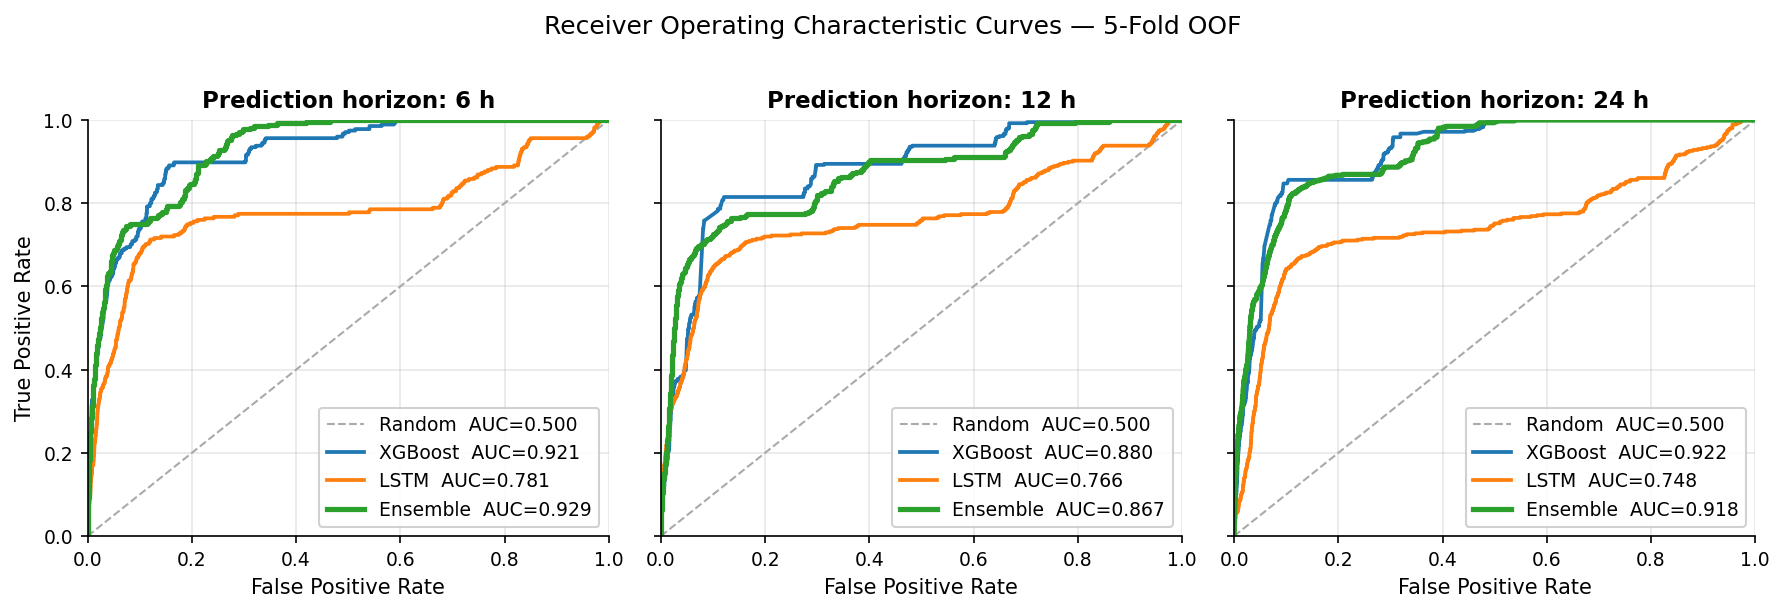

Saved: fig1_roc_curves.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, lbl in zip(axes, LABELS):
    y_true = ens_oof[lbl].values
    ax.plot([0,1],[0,1], color=PALETTE['Random'], ls='--', lw=1, label='Random  AUC=0.500')

    for name, prefix in models:
        col = f'{prefix}{lbl}'
        if col not in ens_oof.columns:
            continue
        fpr, tpr, _ = roc_curve(y_true, ens_oof[col].values)
        auc = roc_auc_score(y_true, ens_oof[col].values)
        lw  = 2.5 if name == 'Ensemble' else 1.8
        ls  = '-'
        ax.plot(fpr, tpr, color=PALETTE[name], lw=lw, ls=ls,
                label=f'{name}  AUC={auc:.3f}')

    ax.set_title(f'Prediction horizon: {HORIZONS[lbl]}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right', framealpha=0.9)

axes[0].set_ylabel('True Positive Rate')
fig.suptitle('Receiver Operating Characteristic Curves — 5-Fold OOF', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_roc_curves.png')
plt.show()
print('Saved: fig1_roc_curves.png')

## 5  Figure 2 — Precision-Recall Curves

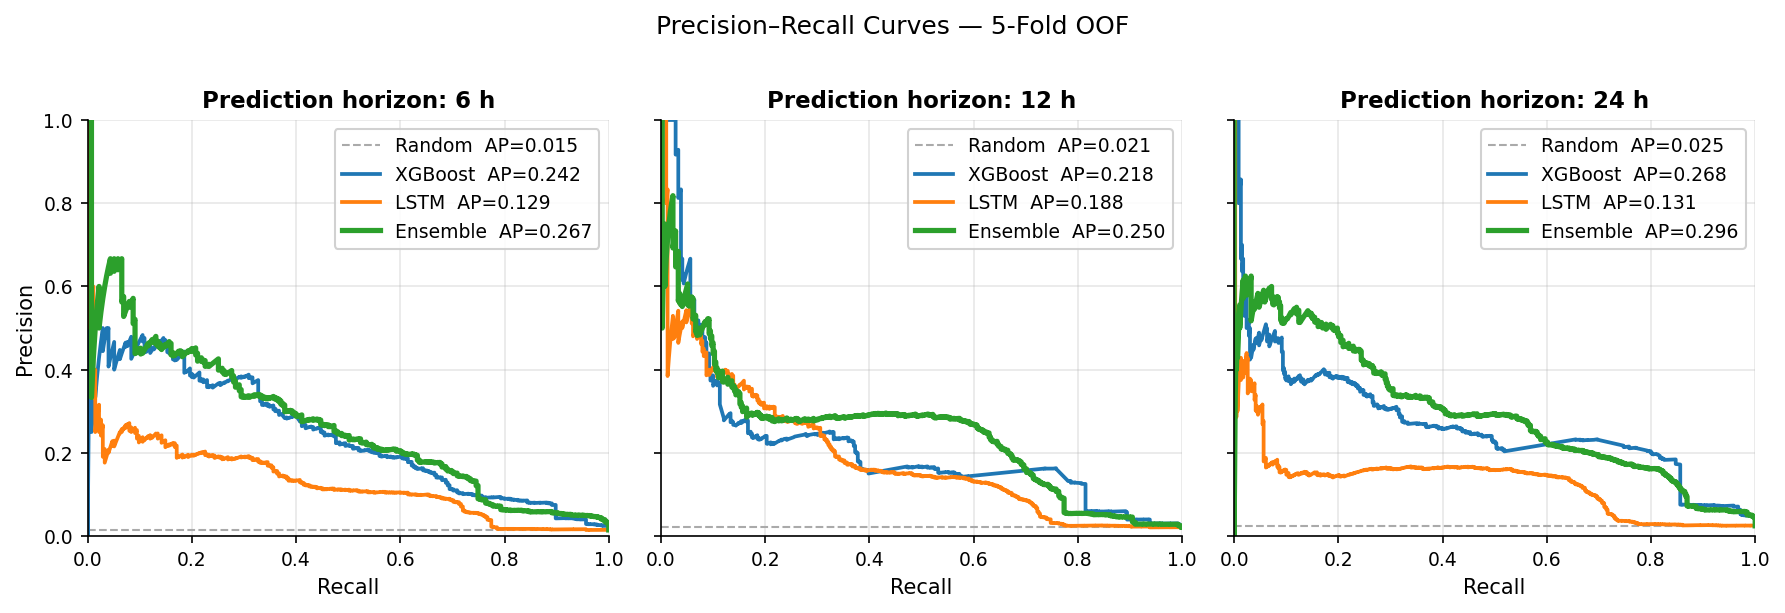

Saved: fig2_pr_curves.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, lbl in zip(axes, LABELS):
    y_true   = ens_oof[lbl].values
    baseline = y_true.mean()
    ax.axhline(baseline, color=PALETTE['Random'], ls='--', lw=1,
               label=f'Random  AP={baseline:.3f}')

    for name, prefix in models:
        col = f'{prefix}{lbl}'
        if col not in ens_oof.columns:
            continue
        prec, rec, _ = precision_recall_curve(y_true, ens_oof[col].values)
        ap  = average_precision_score(y_true, ens_oof[col].values)
        lw  = 2.5 if name == 'Ensemble' else 1.8
        ax.plot(rec, prec, color=PALETTE[name], lw=lw,
                label=f'{name}  AP={ap:.3f}')

    ax.set_title(f'Prediction horizon: {HORIZONS[lbl]}', fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', framealpha=0.9)

axes[0].set_ylabel('Precision')
fig.suptitle('Precision–Recall Curves — 5-Fold OOF', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig2_pr_curves.png')
plt.show()
print('Saved: fig2_pr_curves.png')

## 6  Figure 3 — XGBoost Feature Importance (Gain)

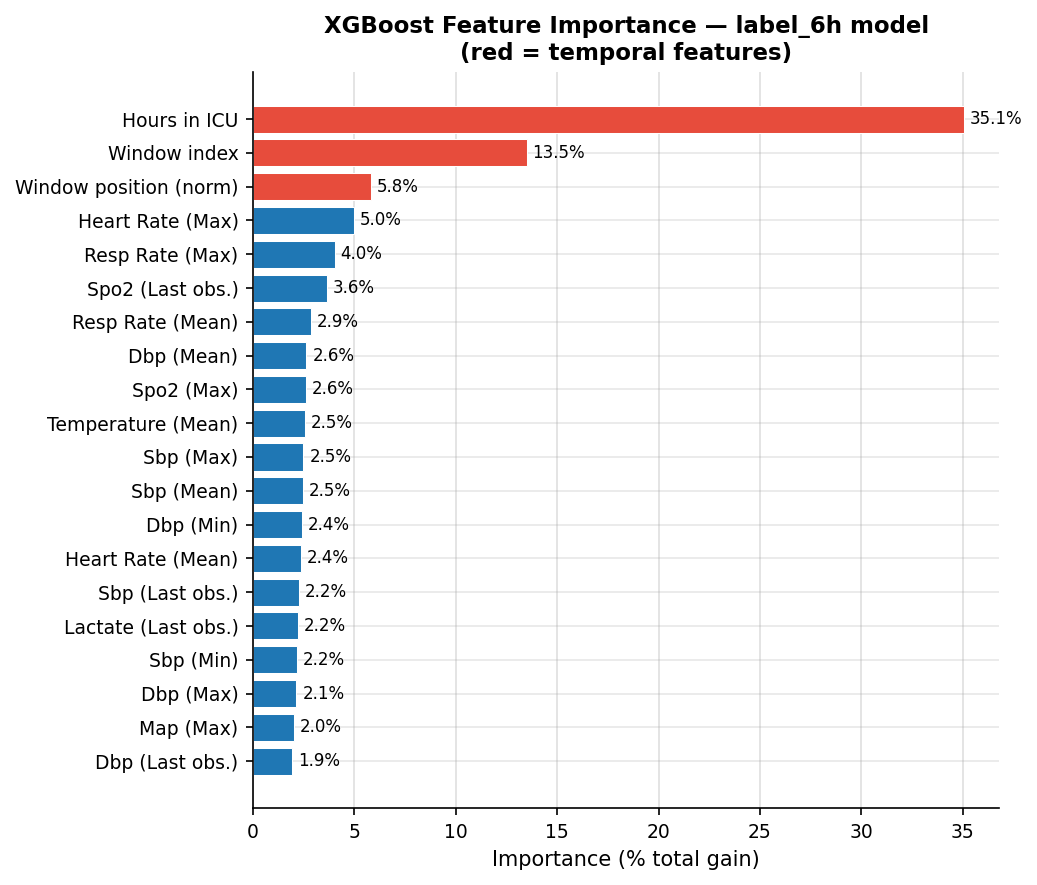

Saved: fig3_feature_importance.png

Top 10 features:
                           Gain %
Hours in ICU            35.062609
Window index            13.487628
Window position (norm)   5.809465
Heart Rate (Max)         4.959246
Resp Rate (Max)          4.021619
Spo2 (Last obs.)         3.636057
Resp Rate (Mean)         2.864065
Dbp (Mean)               2.632887
Spo2 (Max)               2.591360
Temperature (Mean)       2.548925


In [7]:
# Reconstruct feature column names (same order as training script)
LABELS_SET = {'icustay_id','window_start_time','window_end_time',
              'label_6h','label_12h','label_24h'}
raw_feat_cols = [c for c in xgb_raw.columns if c not in LABELS_SET]
feat_cols = raw_feat_cols + ['window_idx', 'window_idx_norm', 'hours_in_icu']
feat_map  = {f'f{i}': name for i, name in enumerate(feat_cols)}

# Load model and extract gain importance
model_6h = xgb.XGBClassifier()
model_6h.load_model(str(MODELS / 'xgb_label_6h.json'))
raw_scores = model_6h.get_booster().get_score(importance_type='gain')

# Map f-indices to readable names
fi_named = {
    feat_map.get(k, k): v
    for k, v in raw_scores.items()
}

# Clean up names for display
def clean_name(name):
    rename = {
        'window_idx_norm': 'Window position (norm)',
        'window_idx':      'Window index',
        'hours_in_icu':    'Hours in ICU',
    }
    if name in rename:
        return rename[name]
    parts = name.rsplit('_', 1)
    if len(parts) == 2:
        signal, stat = parts
        signal = signal.replace('_', ' ').title()
        stat   = {'mean':'Mean','min':'Min','max':'Max','last':'Last obs.'}.get(stat, stat)
        return f'{signal} ({stat})'
    return name

fi_df = (pd.DataFrame.from_dict(fi_named, orient='index', columns=['Gain'])
           .sort_values('Gain', ascending=False)
           .head(20))
fi_df.index = [clean_name(n) for n in fi_df.index]

# Normalize to percentage
fi_df['Gain %'] = fi_df['Gain'] / fi_df['Gain'].sum() * 100

fig, ax = plt.subplots(figsize=(7, 6))
colors  = ['#e74c3c' if 'position' in n.lower() or 'ICU' in n or 'index' in n.lower()
           else '#1f77b4' for n in fi_df.index]
bars = ax.barh(fi_df.index[::-1], fi_df['Gain %'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Importance (% total gain)')
ax.set_title('XGBoost Feature Importance — label_6h model\n'
             '(red = temporal features)', fontweight='bold')
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
for bar, val in zip(bars[::-1], fi_df['Gain %']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig3_feature_importance.png')
plt.show()
print('Saved: fig3_feature_importance.png')
print('\nTop 10 features:')
print(fi_df.head(10)[['Gain %']].to_string())

## 7  Figure 4 — Per-Fold AUROC

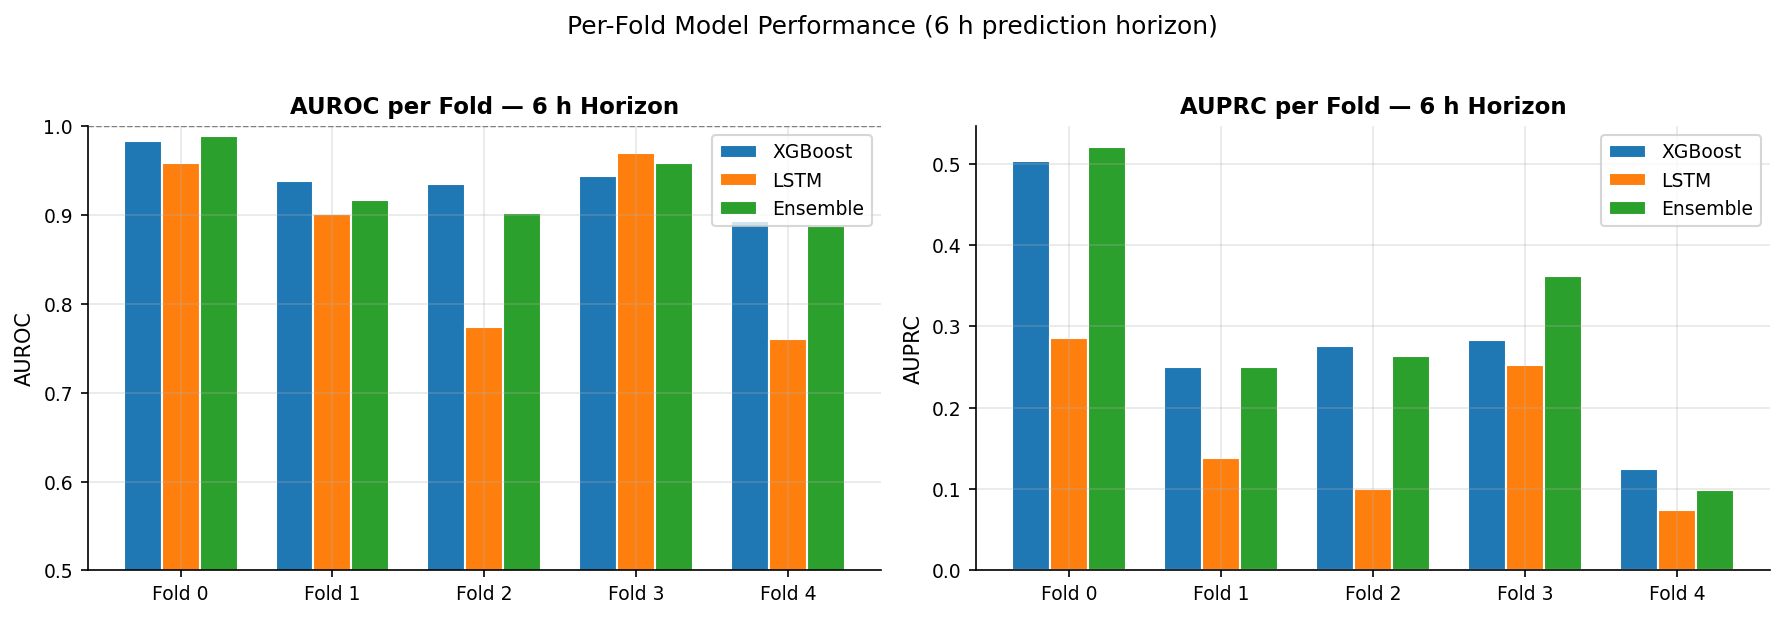

Saved: fig4_fold_performance.png


In [8]:
fold_rows = []
for k in range(5):
    va_ids = set(folds.loc[folds['fold']==k, 'icustay_id'])
    fold_df = ens_oof[ens_oof['icustay_id'].isin(va_ids)]
    for lbl in LABELS:
        yt = fold_df[lbl].values
        if yt.sum() == 0:
            continue
        for name, prefix in models:
            col = f'{prefix}{lbl}'
            if col not in fold_df.columns:
                continue
            fold_rows.append({
                'Fold': f'Fold {k}',
                'Horizon': HORIZONS[lbl],
                'Model': name,
                'AUROC': roc_auc_score(yt, fold_df[col].values),
                'AUPRC': average_precision_score(yt, fold_df[col].values),
            })

fold_perf = pd.DataFrame(fold_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ['AUROC', 'AUPRC']):
    sub = fold_perf[fold_perf['Horizon'] == '6 h']
    x    = np.arange(5)
    w    = 0.25
    for i, (name, _) in enumerate(models):
        vals = sub[sub['Model']==name][metric].values
        ax.bar(x + (i-1)*w, vals, width=w,
               color=PALETTE[name], label=name, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {k}' for k in range(5)])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} per Fold — 6 h Horizon', fontweight='bold')
    if metric == 'AUROC':
        ax.set_ylim(0.5, 1.0)
        ax.axhline(1.0, ls='--', lw=0.7, color='gray')
    ax.legend()

fig.suptitle('Per-Fold Model Performance (6 h prediction horizon)', y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig4_fold_performance.png')
plt.show()
print('Saved: fig4_fold_performance.png')

## 8  Figure 5 — Time-to-Detection Distribution

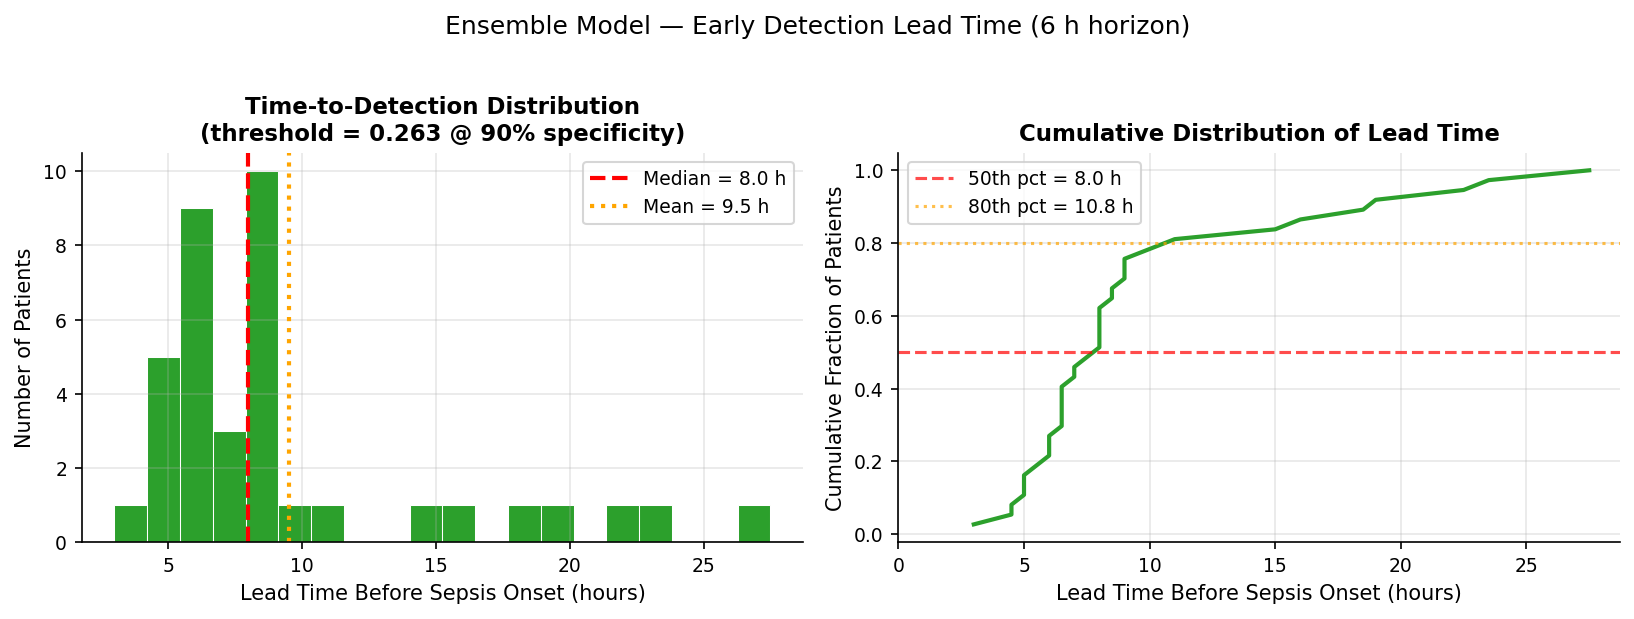

Patients detected before onset  : 37 / 48
Median lead time                : 8.0 h
Mean lead time                  : 9.5 h
% detected > 4 h early          : 97.3%
% detected > 8 h early          : 37.8%
Saved: fig5_time_to_detection.png


In [9]:
def compute_lead_times(df, score_col, threshold, cohort_df):
    """Lead time in hours: how early before onset the model first fires."""
    septic = cohort_df[cohort_df['sepsis_label']==1][['icustay_id','sepsis_onset_time']].copy()
    if hasattr(septic['sepsis_onset_time'].dt, 'tz') and septic['sepsis_onset_time'].dt.tz is not None:
        septic['sepsis_onset_time'] = septic['sepsis_onset_time'].dt.tz_localize(None)
    merged = df.merge(septic, on='icustay_id', how='inner')
    merged = merged[merged['window_end_time'] <= merged['sepsis_onset_time']]
    lead   = []
    for _, grp in merged.groupby('icustay_id'):
        alarms = grp[grp[score_col] >= threshold]
        if alarms.empty:
            continue
        first_alarm = alarms['window_end_time'].min()
        onset       = grp['sepsis_onset_time'].iloc[0]
        h = (onset - first_alarm).total_seconds() / 3600
        if h >= 0:
            lead.append(h)
    return lead

# Find threshold at 90% specificity for ensemble 6h
y_true = ens_oof['label_6h'].values
y_pred = ens_oof['ens_label_6h'].values
fpr, tpr, thresh = roc_curve(y_true, y_pred)
spec = 1 - fpr
mask = spec >= 0.90
thr_90 = float(thresh[mask][-1])

lead_times = compute_lead_times(ens_oof, 'ens_label_6h', thr_90, cohort)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram
ax = axes[0]
ax.hist(lead_times, bins=20, color=PALETTE['Ensemble'],
        edgecolor='white', linewidth=0.5)
ax.axvline(np.median(lead_times), color='red', ls='--', lw=2,
           label=f'Median = {np.median(lead_times):.1f} h')
ax.axvline(np.mean(lead_times),   color='orange', ls=':', lw=2,
           label=f'Mean = {np.mean(lead_times):.1f} h')
ax.set_xlabel('Lead Time Before Sepsis Onset (hours)')
ax.set_ylabel('Number of Patients')
ax.set_title(f'Time-to-Detection Distribution\n'
             f'(threshold = {thr_90:.3f} @ 90% specificity)', fontweight='bold')
ax.legend()

# CDF
ax = axes[1]
sorted_lt = np.sort(lead_times)
cdf = np.arange(1, len(sorted_lt)+1) / len(sorted_lt)
ax.plot(sorted_lt, cdf, color=PALETTE['Ensemble'], lw=2)
ax.axhline(0.5, color='red', ls='--', lw=1.5, alpha=0.7,
           label=f'50th pct = {np.percentile(lead_times,50):.1f} h')
ax.axhline(0.8, color='orange', ls=':', lw=1.5, alpha=0.7,
           label=f'80th pct = {np.percentile(lead_times,80):.1f} h')
ax.set_xlabel('Lead Time Before Sepsis Onset (hours)')
ax.set_ylabel('Cumulative Fraction of Patients')
ax.set_title('Cumulative Distribution of Lead Time', fontweight='bold')
ax.set_xlim(left=0)
ax.legend()

fig.suptitle('Ensemble Model — Early Detection Lead Time (6 h horizon)', y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_time_to_detection.png')
plt.show()

print(f'Patients detected before onset  : {len(lead_times)} / {int(cohort["sepsis_label"].sum())}')
print(f'Median lead time                : {np.median(lead_times):.1f} h')
print(f'Mean lead time                  : {np.mean(lead_times):.1f} h')
print(f'% detected > 4 h early          : {np.mean(np.array(lead_times)>4)*100:.1f}%')
print(f'% detected > 8 h early          : {np.mean(np.array(lead_times)>8)*100:.1f}%')
print(f'Saved: fig5_time_to_detection.png')

## 9  Figure 6 — Label Prevalence Across Horizons

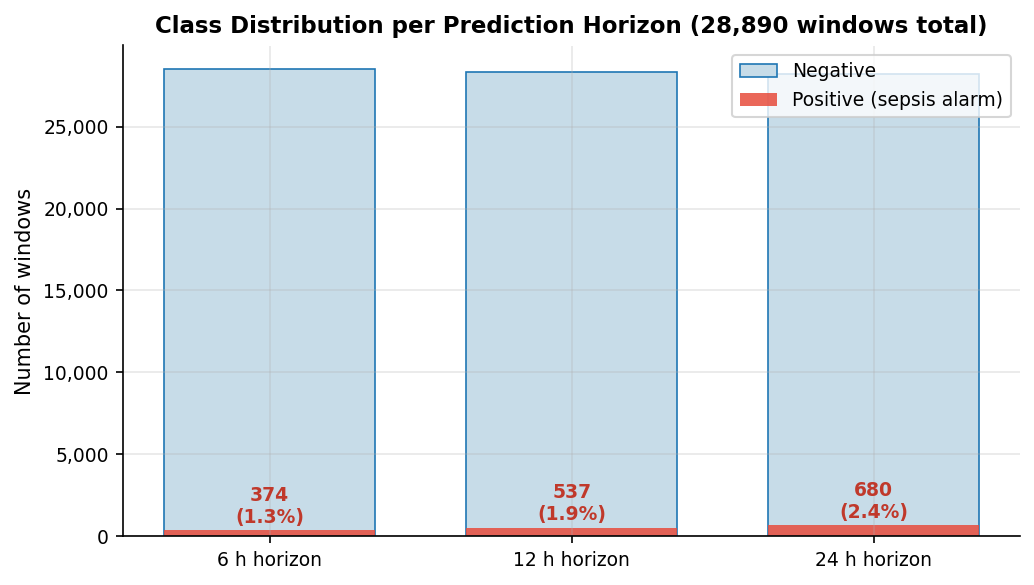

Saved: fig6_label_distribution.png


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

pos_counts = {HORIZONS[l]: int(xgb_oof[l].sum()) for l in LABELS}
neg_counts = {HORIZONS[l]: len(xgb_oof) - int(xgb_oof[l].sum()) for l in LABELS}

x   = np.arange(3)
w   = 0.35
ax.bar(x, [neg_counts[h] for h in HORIZONS.values()],
       width=w*2, label='Negative', color='#c7dce8', edgecolor='#1f77b4', lw=0.8)
ax.bar(x, [pos_counts[h] for h in HORIZONS.values()],
       width=w*2, label='Positive (sepsis alarm)', color='#e74c3c', alpha=0.85)

for xi, lbl in zip(x, LABELS):
    n_pos = int(xgb_oof[lbl].sum())
    prev  = xgb_oof[lbl].mean() * 100
    ax.text(xi, n_pos + 200, f'{n_pos:,}\n({prev:.1f}%)',
            ha='center', va='bottom', fontsize=9, color='#c0392b', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{h} horizon' for h in HORIZONS.values()])
ax.set_ylabel('Number of windows')
ax.set_title('Class Distribution per Prediction Horizon (28,890 windows total)',
             fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6_label_distribution.png')
plt.show()
print('Saved: fig6_label_distribution.png')

## 10  Figure 7 — Combined Summary Panel (Paper-Ready)

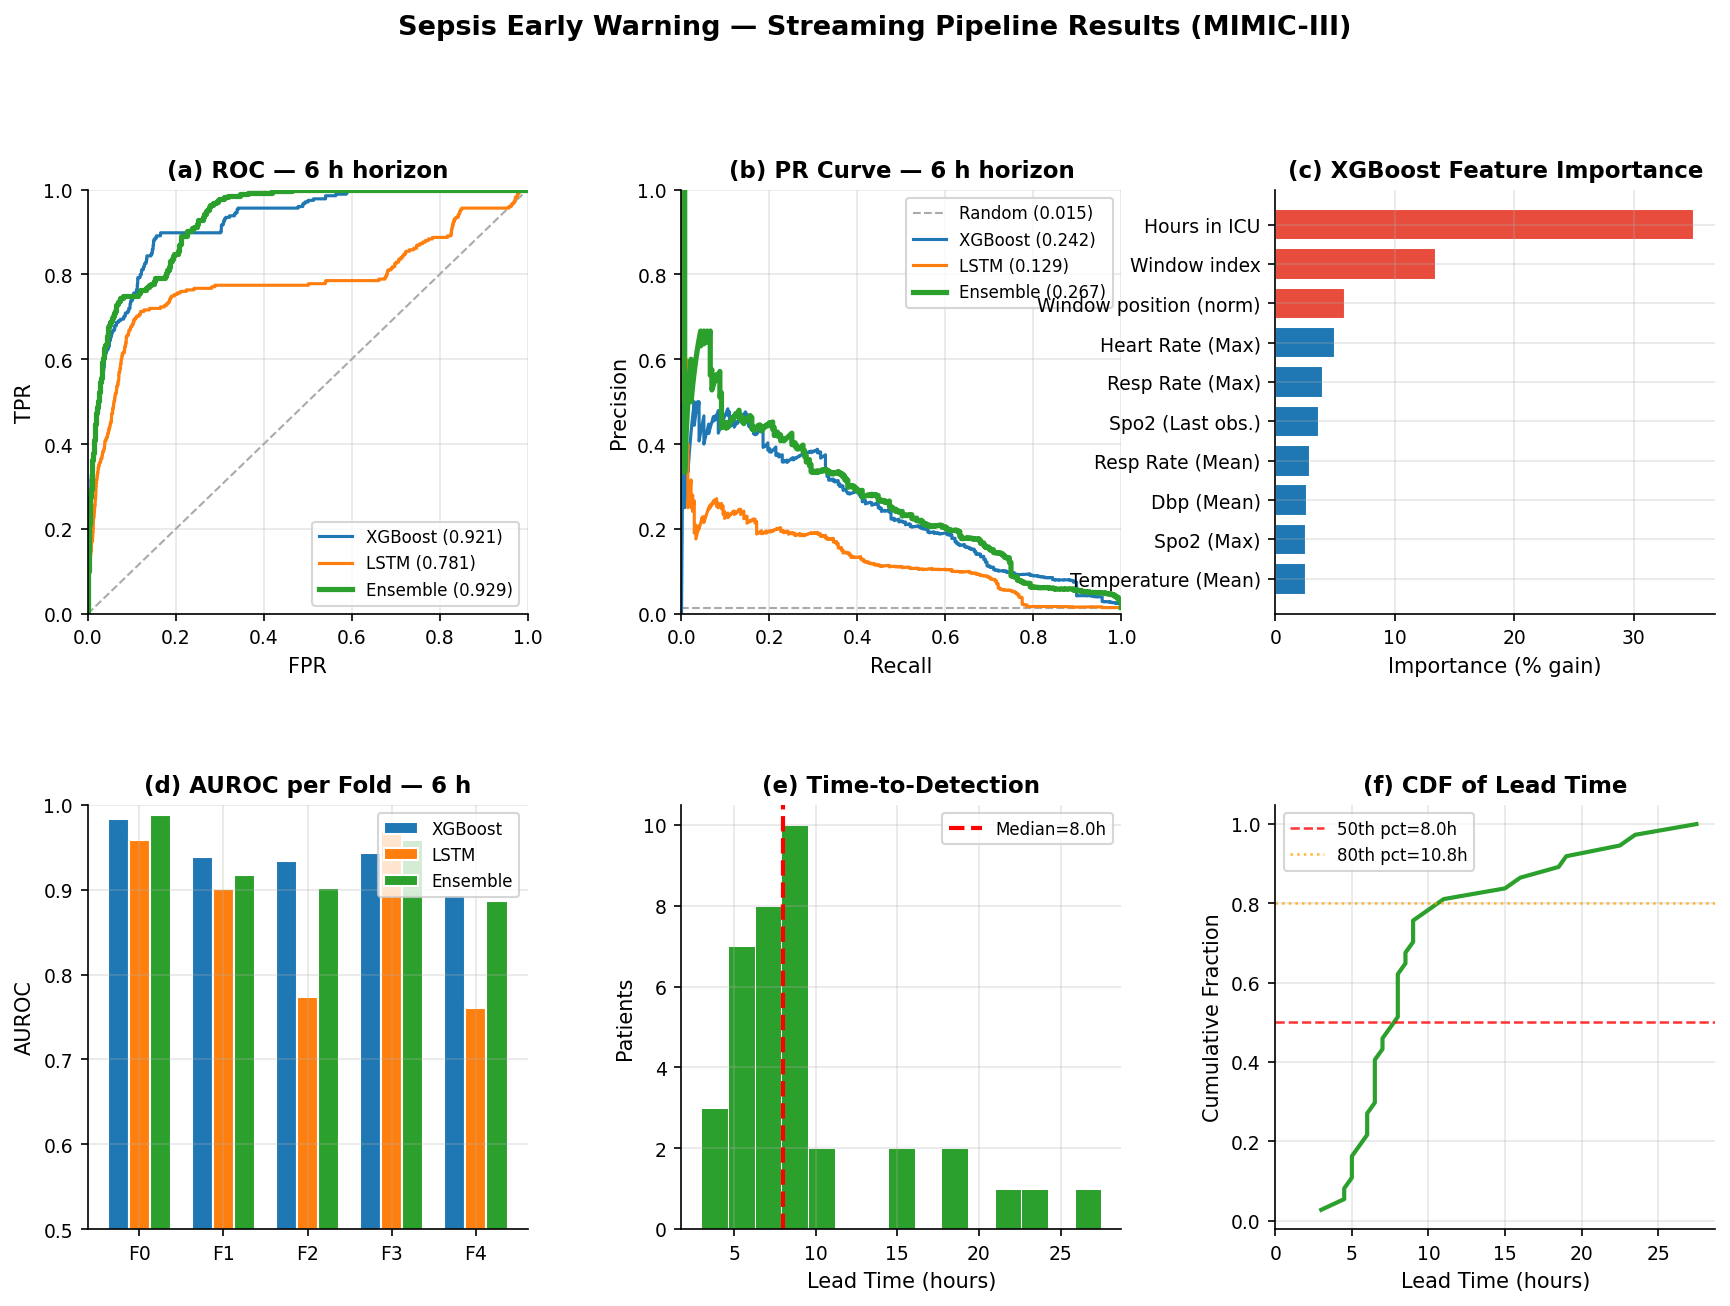

Saved: fig7_summary_panel.png  ← main paper figure


In [11]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Row 0: ROC (6h), PR (6h), Feature importance
ax_roc = fig.add_subplot(gs[0, 0])
ax_pr  = fig.add_subplot(gs[0, 1])
ax_fi  = fig.add_subplot(gs[0, 2])

# Row 1: Per-fold AUROC, Time-to-detection histogram, Time-to-detection CDF
ax_fold = fig.add_subplot(gs[1, 0])
ax_hist = fig.add_subplot(gs[1, 1])
ax_cdf  = fig.add_subplot(gs[1, 2])

# ── ROC (6h) ──────────────────────────────────────────────────────────────
y_true = ens_oof['label_6h'].values
ax_roc.plot([0,1],[0,1], color=PALETTE['Random'], ls='--', lw=1)
for name, prefix in models:
    col = f'{prefix}label_6h'
    if col not in ens_oof.columns: continue
    fpr_, tpr_, _ = roc_curve(y_true, ens_oof[col].values)
    auc_ = roc_auc_score(y_true, ens_oof[col].values)
    ax_roc.plot(fpr_, tpr_, color=PALETTE[name],
                lw=2.5 if name=='Ensemble' else 1.5,
                label=f'{name} ({auc_:.3f})')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('(a) ROC — 6 h horizon', fontweight='bold')
ax_roc.legend(fontsize=8, loc='lower right')
ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1)

# ── PR (6h) ────────────────────────────────────────────────────────────────
baseline = y_true.mean()
ax_pr.axhline(baseline, color=PALETTE['Random'], ls='--', lw=1,
              label=f'Random ({baseline:.3f})')
for name, prefix in models:
    col = f'{prefix}label_6h'
    if col not in ens_oof.columns: continue
    prec_, rec_, _ = precision_recall_curve(y_true, ens_oof[col].values)
    ap_ = average_precision_score(y_true, ens_oof[col].values)
    ax_pr.plot(rec_, prec_, color=PALETTE[name],
               lw=2.5 if name=='Ensemble' else 1.5,
               label=f'{name} ({ap_:.3f})')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('(b) PR Curve — 6 h horizon', fontweight='bold')
ax_pr.legend(fontsize=8, loc='upper right')
ax_pr.set_xlim(0,1); ax_pr.set_ylim(0,1)

# ── Feature Importance ─────────────────────────────────────────────────────
top10 = fi_df.head(10)
colors_fi = ['#e74c3c' if 'position' in n.lower() or 'ICU' in n or 'index' in n.lower()
             else '#1f77b4' for n in top10.index]
ax_fi.barh(top10.index[::-1], top10['Gain %'][::-1],
           color=colors_fi[::-1], edgecolor='white')
ax_fi.set_xlabel('Importance (% gain)')
ax_fi.set_title('(c) XGBoost Feature Importance', fontweight='bold')

# ── Per-fold AUROC (6h) ─────────────────────────────────────────────────────
sub6 = fold_perf[fold_perf['Horizon']=='6 h']
xf   = np.arange(5)
for i, (name, _) in enumerate(models):
    vals = sub6[sub6['Model']==name]['AUROC'].values
    ax_fold.bar(xf + (i-1)*0.25, vals, width=0.25,
                color=PALETTE[name], label=name, edgecolor='white')
ax_fold.set_xticks(xf)
ax_fold.set_xticklabels([f'F{k}' for k in range(5)])
ax_fold.set_ylabel('AUROC')
ax_fold.set_ylim(0.5, 1.0)
ax_fold.set_title('(d) AUROC per Fold — 6 h', fontweight='bold')
ax_fold.legend(fontsize=8)

# ── Lead time histogram ─────────────────────────────────────────────────────
ax_hist.hist(lead_times, bins=15, color=PALETTE['Ensemble'],
             edgecolor='white', linewidth=0.5)
ax_hist.axvline(np.median(lead_times), color='red', ls='--', lw=2,
                label=f'Median={np.median(lead_times):.1f}h')
ax_hist.set_xlabel('Lead Time (hours)')
ax_hist.set_ylabel('Patients')
ax_hist.set_title('(e) Time-to-Detection', fontweight='bold')
ax_hist.legend(fontsize=8)

# ── Lead time CDF ──────────────────────────────────────────────────────────
ax_cdf.plot(sorted_lt, cdf, color=PALETTE['Ensemble'], lw=2)
ax_cdf.axhline(0.5, color='red',    ls='--', lw=1.2, alpha=0.8,
               label=f'50th pct={np.percentile(lead_times,50):.1f}h')
ax_cdf.axhline(0.8, color='orange', ls=':',  lw=1.2, alpha=0.8,
               label=f'80th pct={np.percentile(lead_times,80):.1f}h')
ax_cdf.set_xlabel('Lead Time (hours)')
ax_cdf.set_ylabel('Cumulative Fraction')
ax_cdf.set_title('(f) CDF of Lead Time', fontweight='bold')
ax_cdf.set_xlim(left=0)
ax_cdf.legend(fontsize=8)

fig.suptitle('Sepsis Early Warning — Streaming Pipeline Results (MIMIC-III)',
             fontsize=13, fontweight='bold', y=1.01)
fig.savefig(FIG_DIR / 'fig7_summary_panel.png')
plt.show()
print('Saved: fig7_summary_panel.png  ← main paper figure')

## 11  Paper Statistics Summary

In [12]:
print('=' * 65)
print('KEY NUMBERS FOR THE PAPER')
print('=' * 65)

n_pts    = len(cohort)
n_septic = int(cohort['sepsis_label'].sum())
n_win    = len(xgb_oof)

print(f'\nDataset')
print(f'  Patients             : {n_pts}  ({n_septic} septic, {n_pts-n_septic} non-septic)')
print(f'  ICU windows          : {n_win:,}')
print(f'  Signals              : 12 vitals/labs × 30-min sliding window')
print(f'  Features (XGBoost)   : 51  (48 raw + 3 temporal)')
print(f'  Features (LSTM)      : 25  (12 forward-filled + 12 binary freshness + position)')
print(f'  CV strategy          : 5-fold patient-level stratified')

print(f'\nModel Performance (5-fold OOF, ensemble XGBoost + LSTM)')
for lbl in LABELS:
    yt = ens_oof[lbl].values
    yp = ens_oof[f'ens_{lbl}'].values
    auroc = roc_auc_score(yt, yp)
    auprc = average_precision_score(yt, yp)
    s90   = sens_at_spec(yt, yp, 0.90)
    baseline = yt.mean()
    lift     = auprc / baseline
    print(f'  {HORIZONS[lbl]:>5} horizon: AUROC={auroc:.4f}  '
          f'AUPRC={auprc:.4f}  Sens@90%Sp={s90:.3f}  '
          f'AUPRC lift={lift:.1f}x vs random')

print(f'\nTime-to-Detection (ensemble, 6h horizon, threshold@90%Sp={thr_90:.3f})')
print(f'  Patients detected   : {len(lead_times)} / {n_septic}')
print(f'  Median lead time    : {np.median(lead_times):.1f} h before onset')
print(f'  Mean lead time      : {np.mean(lead_times):.1f} h')
print(f'  Detected > 4 h early: {np.mean(np.array(lead_times)>4)*100:.0f}% of detected patients')
print(f'  Detected > 8 h early: {np.mean(np.array(lead_times)>8)*100:.0f}% of detected patients')

print(f'\nAll figures saved to: {FIG_DIR}')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}')

KEY NUMBERS FOR THE PAPER

Dataset
  Patients             : 136  (48 septic, 88 non-septic)
  ICU windows          : 28,890
  Signals              : 12 vitals/labs × 30-min sliding window
  Features (XGBoost)   : 51  (48 raw + 3 temporal)
  Features (LSTM)      : 25  (12 forward-filled + 12 binary freshness + position)
  CV strategy          : 5-fold patient-level stratified

Model Performance (5-fold OOF, ensemble XGBoost + LSTM)
    6 h horizon: AUROC=0.9294  AUPRC=0.2674  Sens@90%Sp=0.749  AUPRC lift=18.1x vs random
   12 h horizon: AUROC=0.8674  AUPRC=0.2495  Sens@90%Sp=0.725  AUPRC lift=12.0x vs random
   24 h horizon: AUROC=0.9182  AUPRC=0.2964  Sens@90%Sp=0.784  AUPRC lift=12.1x vs random

Time-to-Detection (ensemble, 6h horizon, threshold@90%Sp=0.263)
  Patients detected   : 37 / 48
  Median lead time    : 8.0 h before onset
  Mean lead time      : 9.5 h
  Detected > 4 h early: 97% of detected patients
  Detected > 8 h early: 38% of detected patients

All figures saved to: E:\B